# Monte Carlo Simulations

This notebook shows examples of Monte Carlo simulations for: *(a)* the distribution from a GARCH process; *(b)* the effect of heteroskedasticity on OLS standard errors.

## Load Packages and Extra Functions

The key functions for simulations are coded in this notebook. However, the function for OLS is from the (local) `FinEcmt_OLS` module.

In [1]:
MyModulePath = joinpath(pwd(),"src")
!in(MyModulePath,LOAD_PATH) && push!(LOAD_PATH,MyModulePath)
using FinEcmt_OLS

In [2]:
#=
include(joinpath(pwd(),"src","FinEcmt_OLS.jl"))
using .FinEcmt_OLS
=#

In [3]:
using Random, LinearAlgebra, Distributions

In [4]:
using Plots, LaTeXStrings
default(size = (480,320),fmt = :png)

# Simulating the Distribution of a GARCH(1,1) Variable

The `GarchSim(T,ω,α,β)` function (see below) generates $T$ observations of a variable $u_t$ whose conditional distribution (based on information in $t-1$) is $N(0,\sigma_t^2)$, where $\sigma_t^2$ follows a GARCH(1,1) process:

$\sigma_{t}^{2}    =\omega+\alpha u_{t-1}^{2}+\beta\sigma_{t-1}^{2}.$

The subsequent cells call on the `GarchSim()` function and plots a histogram of the simulated values. This is repeated for two different values of $\alpha$: a high value and a low value.

In [5]:
"""
    GarchSim(T,ω,α,β)

Simulate a time series of T residuals from a GARCH(1,1) process.

### Remark
- The vector of σ² values is not exported from the function. 
If needed, this could easily be changed.

"""
function GarchSim(T,ω,α,β)
    (σ²,u) = [zeros(T) for i=1:2]
    σ²[1]  = ω/(1-α-β)                              #average σ² as starting value
    for t in 2:T
        σ²[t] = ω + α*u[t-1]^2 + β*σ²[t-1]
        u[t]  = sqrt(σ²[t])*randn()
    end
    return u
end

GarchSim

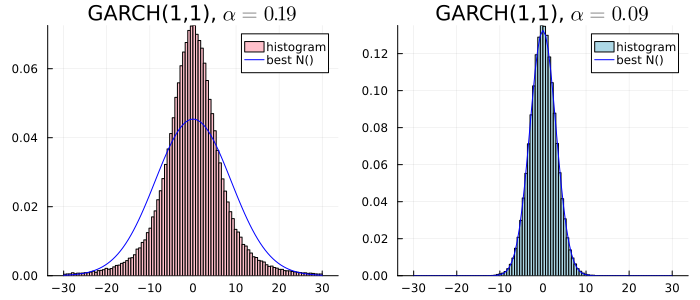

In [6]:
(T,ω,β) = (200_000,1,0.8)         
(αH,αL) = (0.19,0.09)                           #fairly high and low α values  
                                          
Random.seed!(123456)                            #to replicate the same random numbers
u = GarchSim(T,ω,αH,β)
uGrid = range(-30,30,length=101)                #grid of values
pdfNu = pdf.(Normal(mean(u),std(u)),uGrid)      #best fitting N() as a comparison

ub = GarchSim(T,ω,αL,β)
pdfNub = pdf.(Normal(mean(ub),std(ub)),uGrid)

p1 = histogram( u,
                bins = uGrid,
                fillcolor = :pink,
                normalized = true,
                label = "histogram",
                title = L"GARCH(1,1), $\alpha = %$αH$" )
plot!(uGrid,pdfNu,color=:blue,label="best N()")

p2 = histogram( ub,
                bins = uGrid,
                fillcolor = :lightblue,
                normalized = true,
                label = "histogram",
                title = L"GARCH(1,1), $\alpha = %$αL$" )
plot!(uGrid,pdfNub,color=:blue,label="best N()")

pAll = plot(p1,p2,layout=(1,2),size=(700,300))                  #set up subplots
display(pAll)

# Simulating (White's) Heteroskedasticity in OLS

The `SimOL(NSim,T,α)` function (see below) first simulates `T` observations where the residuals in an OLS regression are heteroskedastic, since they are generated as 

$\epsilon_t = u_t \sigma_t,$
where 
$\sigma_t^2 = (1+\alpha |x_t-2|)^2$


where $u_t$ is $N(0,1)$ and $x_t$ is a regressor distributed as $N(2,1)$.

The function then estimates the traditional OLS standard errors and also White's standard errors.

The subsequent cell compares the different standard errors in two cases: $\alpha=0$ and $\alpha=1$.

In [7]:
"""
    SimOLS(NSim,T,α)

Simulate data for a regression model with heteroskedastic errors and then estimate both point estimates
and standard errors according to traditional OLS (Gauss-Markov) and White.

### Input
- `NSim::Int`:    number of simulations (eg. 3000)
- `T::Int`:       sample length (eg. 200)
- `α::Number`:    degree of heteroskedasticity

"""
function SimOLS(NSim,T,α)

    (bLS,StdLS,StdWhite) = [fill(NaN,NSim,2) for i = 1:3]
    for i in 1:NSim
        x = randn(T) .+ 2                     #some random regressors
        σ² = (1 .+ α*abs.(x.-2)).^2 
        ϵ = randn(T) .* sqrt.(σ²)             #heteroskedastic residuals
        y = 1 .+ 0.9*x + ϵ
        x = [x ones(T)]
        (b,u,) = OlsGM(y,x)                   #OLS, point estimates
        bLS[i,:] = b
        Sxx           = x'x
        S             = (x.*u)'*(x.*u)
        V_W           = inv(Sxx)'S*inv(Sxx)      #Cov(b), White
        StdWhite[i,:] = sqrt.(diag(V_W))
        V_iid         = inv(Sxx)*var(u)          #OLS, traditional
        StdLS[i,:]    = sqrt.(diag(V_iid))
    end

    return bLS, StdLS, StdWhite

end

SimOLS

In [8]:
(T,NSim) = (200,25000)           #number of simulated samples
Random.seed!(123456)

α = 0                            #no heteroskedasticity
(bLS,StdLS,StdWhite) = SimOLS(NSim,T,α)

αH = 1                           #lots of heteroskedasticity
(bLSb,StdLSb,StdWhiteb) = SimOLS(NSim,T,αH)


colNames = ["Simulated","OLS","White"]
rowNames=["slope","intercept"]
printblue("Standard errors when α=$(α):")
printmat(std(bLS,dims=1)',mean(StdLS,dims=1)',mean(StdWhite,dims=1)';colNames,rowNames)

printblue("Standard errors when α=$(αH):")
printmat(std(bLSb,dims=1)',mean(StdLSb,dims=1)',mean(StdWhiteb,dims=1)';colNames,rowNames)

printred("The standard errors from different methods are similar when α=0, but different otherwise")

Standard errors when α=0:
          Simulated       OLS     White
slope         0.071     0.071     0.070
intercept     0.159     0.158     0.157

Standard errors when α=1:
          Simulated       OLS     White
slope         0.190     0.134     0.185
intercept     0.403     0.299     0.392

The standard errors from different methods are similar when α=0, but different otherwise
